# 0.35 — Quarterly-rebalance basket test: quantum & genAI, each from its own info date

**Strategy**: equal weights, buy at the basket's information date, hold 3 months, rebalance, repeat
(contiguous periods: each exit day *is* the next entry day; final position marked at the end date).

**Formulas** — per period $i$, over held names $H_i$ (those with a price at $t_i$):

$$r_i = \tfrac{1}{|H_i|}\textstyle\sum_{j \in H_i}\bigl(P_j(t_{i+1})/P_j(t_i) - 1\bigr)
\qquad R=\textstyle\sum_i r_i \qquad \text{ratio}=R/\sigma \qquad
\text{Sharpe}_{ann}=\bar r/\sigma\cdot\sqrt{4}$$

$P$ = Yahoo **auto-adjusted** closes (`auto_adjust=True`, splits+dividends folded in), cached under
`data/raw/prices/`. $\sigma$ = std of the $r_i$ (ddof=1). The two baskets start on **different
information dates**, so their windows have different $n$: the ratio $R/\sigma = n\bar r/\sigma$ is
comparable only *within* a window (basket vs its own SPY) — across baskets use **Sharpe** (per-period
mean/std, annualized), which is horizon-free. Each section benchmarks SPY on the *same* window.

**Ticker provenance** — the pipeline's own EDGAR baskets (`build_theme_basket.py`, mention counts in
10-K/10-Q filings; recorded in 0.33/0.34):
**quantum** = rule-selected at info date **2022-09-30** (same 4 names re-confirmed 2025-01-15):
`IONQ QUBT RGTI QBTS` · **genAI** = point-in-time top-10 at info date **2023-01-17** (last filing
2023-01-10, no look-ahead): `NVDA TRIP GOOG EA MYPS APPS EXPE EBAY CRNC FFAI`.

In [1]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import pandas as pd
import matplotlib.pyplot as plt
import theme_backtest as bt

QUANTUM = dict(ticks=["IONQ", "QUBT", "RGTI", "QBTS"], start="2022-09-30", color="#2a78d6")
GENAI   = dict(
    #ticks=["MSFT", "NVDA", "GOOGL", "BIDU", "BABA", "NTES", "AMZN"], 
    ticks=["NVDA", "TRIP", "GOOG", "EA", "MYPS", "APPS", "EXPE", "EBAY", "CRNC", "FFAI"], 
    start="2023-05-18", color="#eb6834")
END = "2025-12-31"
MONTHS = 3                      # <-- rebalance frequency in months: change it only here
GRAY = "#7a7a75"

px = bt.load_prices(sorted(set(QUANTUM["ticks"]) | set(GENAI["ticks"]) | {"SPY"}))

def report(name, ticks, start, end=END, months=MONTHS):
    """Basket vs SPY on the same window: summed period returns, std, ratio, annualized Sharpe."""
    print(f"window {start} -> {end} · rebalance every {months}m")
    print(f"{'':9}{'n':>3} {'sum rets':>10} {'std':>7} {'ret/risk':>9} {'Sharpe ann':>11}")
    out = {}
    for label, tk in [(name, ticks), ("SPY", ["SPY"])]:
        r, tot, ratio = bt.rebalance_backtest(px, tk, start, end, months=months)
        sh = float(r.mean() / r.std(ddof=1) * (12 / months) ** 0.5)   # periods/year annualization
        print(f"{label:9}{len(r):>3} {tot:>10.1%} {r.std(ddof=1):>7.1%} {ratio:>9.2f} {sh:>11.2f}")
        out[label] = r
    return pd.DataFrame(out)

def plot_curves(name, ticks, start, color, end=END, months=MONTHS):
    fig, ax = plt.subplots(figsize=(9, 4.2))
    for label, tk, col, ls, lw in [(name, ticks, color, "-", 2), ("SPY", ["SPY"], GRAY, "--", 1.6)]:
        c = bt.rebalance_curve(px, tk, start, end, months=months)
        ax.plot(c.index, c, color=col, ls=ls, lw=lw, label=label)
        ax.annotate(f" {label} {c.iloc[-1] - 1:+.0%}", (c.index[-1], c.iloc[-1]),
                    color=col, fontsize=9, fontweight="bold", va="center")
    ax.set_yscale("log"); ax.set_yticks([0.25, 0.5, 1, 2, 4, 8, 16, 32])
    ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:g}x"))
    ax.grid(alpha=0.25, lw=0.5); ax.spines[["top", "right"]].set_visible(False)
    ax.set_title(f"{name} — equal weight, {months}m rebalance, from its info date {start} (log)", fontsize=11)
    ax.legend(frameon=False, loc="upper left"); ax.margins(x=0.12)
    plt.tight_layout(); plt.show()

print("prices ready:", px.shape[1], "tickers")

prices ready: 15 tickers


## 1 · Quantum — from its info date 2022-09-30

In [2]:
rq = report("quantum", QUANTUM["ticks"], QUANTUM["start"])
print(); print(rq.to_string(float_format="{:+.1%}".format))

window 2022-09-30 -> 2025-12-31 · rebalance every 3m
           n   sum rets     std  ret/risk  Sharpe ann
quantum   14    1669.6%  405.9%      4.11        0.59
SPY       14      72.5%    5.2%     13.99        2.00

            quantum    SPY
2022-09-30   -53.7%  +7.6%
2022-12-30   -13.4%  +6.0%
2023-03-30  +140.2% +10.2%
2023-06-30   -11.1%  -3.3%
2023-10-02   -19.3% +11.1%
2024-01-02   +48.5% +10.8%
2024-04-01   -41.7%  +4.8%
2024-07-01   +13.1%  +5.5%
2024-09-30 +1515.8%  +2.9%
2024-12-30   -44.7%  -4.6%
2025-03-31   +94.2% +10.8%
2025-06-30   +64.8%  +8.1%
2025-09-30   -22.1%  +3.4%
2025-12-30    -1.0%  -0.7%


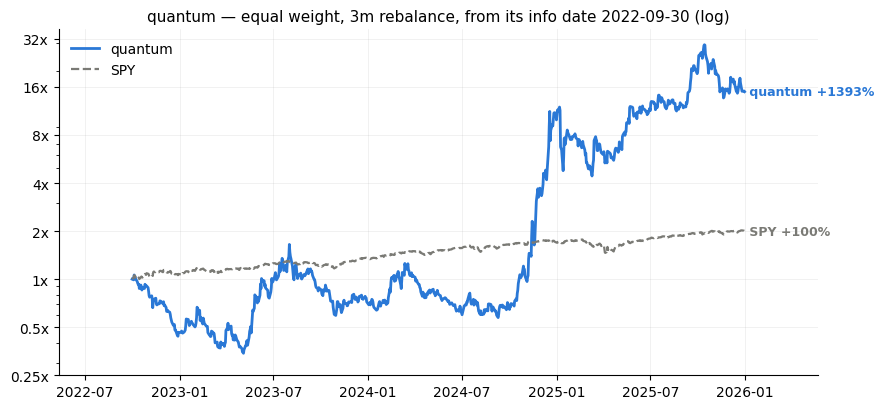

In [3]:
plot_curves("quantum", QUANTUM["ticks"], QUANTUM["start"], QUANTUM["color"])

## 2 · genAI — from its info date 2023-01-17

In [4]:
rg = report("genai", GENAI["ticks"], GENAI["start"])
print(); print(rg.to_string(float_format="{:+.1%}".format))

window 2023-05-18 -> 2025-12-31 · rebalance every 3m
           n   sum rets     std  ret/risk  Sharpe ann
genai     11     120.8%   29.1%      4.15        0.75
SPY       11      54.0%    3.2%     16.85        3.06

            genai   SPY
2023-05-18  -0.2% +4.5%
2023-08-18 -11.2% +4.4%
2023-11-20  -4.9% +9.8%
2024-02-20 +55.6% +7.0%
2024-05-20  -1.0% +5.9%
2024-08-19  -7.8% +5.4%
2024-11-18 +75.2% +4.3%
2025-02-18 -11.6% -2.4%
2025-05-19 +25.4% +8.5%
2025-08-18  -5.7% +2.9%
2025-11-18  +7.1% +3.6%


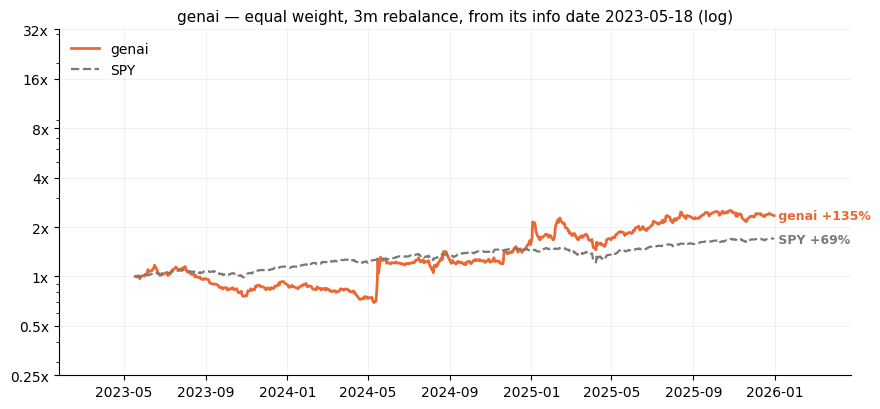

In [5]:
plot_curves("genai", GENAI["ticks"], GENAI["start"], GENAI["color"])

## 3 · genAI from the news co-mention graph — no SEC filings

Same theme, same detection, **different word→company mapping**: instead of counting theme words
in SEC filings (which lag a 7-week-old theme), take the listed companies that the detection itself
co-mentions with the `chatgpt` anchor (its *partners* in the 0.28 funnel output), point-in-time:

- **news-core** — partners visible by end-Jan 2023 (`microsoft`, `nvidia`, `google`) → entry **2023-02-01**;
- **news-ecosystem** — adds the names appearing during Feb 2023 (`baidu`, `alibaba`, `netease`, `amazon`) → entry **2023-03-01**.

(`openai` is private, `samsung` not US-listed — excluded.) Source of the "Sharpe 1.94" claim in deck VIII.

**N.B. (window sensitivity):** on the March window SPY's own Sharpe jumps to 2.37 — the one-month
grid shift places the March-2023 SVB drawdown *inside* a quarter, invisible to quarterly endpoint
marks. So news-core beats its same-window index (1.94 vs 1.37) while news-eco (1.99) does not
(2.37). Endpoint sampling matters: one more reason the good/bad theme classifier must average over
entry dates rather than trust a single grid.

In [6]:
NEWS_CORE = dict(ticks=["MSFT", "NVDA", "GOOGL"], start="2023-02-01", color="#1baf7a")
NEWS_ECO  = dict(ticks=["MSFT", "NVDA", "GOOGL", "BIDU", "BABA", "NTES", "AMZN"],
                 start="2023-03-01", color="#1baf7a")

px = bt.load_prices(sorted(set(px.columns) | set(NEWS_ECO["ticks"])))   # extend the price frame

rc = report("news-core", NEWS_CORE["ticks"], NEWS_CORE["start"])
print()
re_ = report("news-eco", NEWS_ECO["ticks"], NEWS_ECO["start"])

window 2023-02-01 -> 2025-12-31 · rebalance every 3m
           n   sum rets     std  ret/risk  Sharpe ann
news-core 12     160.2%   13.8%     11.63        1.94
SPY       12      58.6%    7.1%      8.24        1.37

window 2023-03-01 -> 2025-12-31 · rebalance every 3m
           n   sum rets     std  ret/risk  Sharpe ann
news-eco  12     105.7%    8.8%     11.95        1.99
SPY       12      61.0%    4.3%     14.24        2.37


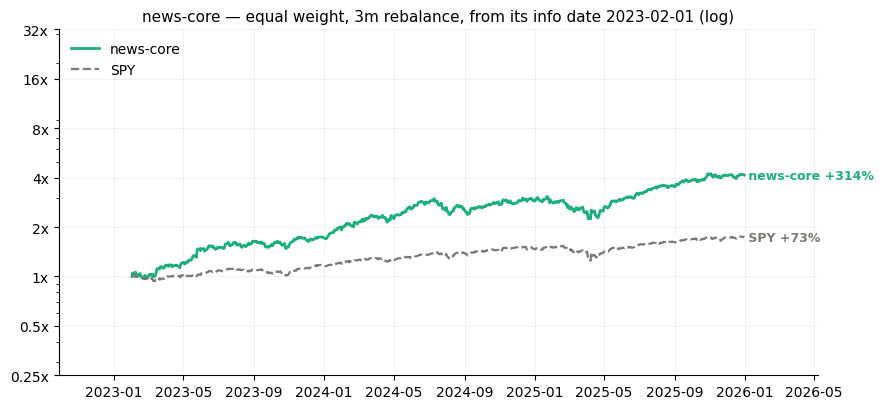

In [7]:
plot_curves("news-core", NEWS_CORE["ticks"], NEWS_CORE["start"], NEWS_CORE["color"])

## Reading the two experiments together

The windows differ, so compare across baskets with **Sharpe (annualized)** only; the `ret/risk`
column is fair only against the SPY row *inside the same section*. Caveats that stand regardless:
quantum's result is dominated by a single quarter (Q4-2024), genAI's by a single name (NVDA — see
0.33's decomposition), and pre-merger SPAC history means the earliest quantum quarters trade
near-shell prices for RGTI/QBTS.